# Task
Perform an exploratory data analysis on the `titanic.csv` dataset, including loading the data, initial data inspection, handling missing values, univariate analysis of numerical and categorical features, bivariate analysis with the 'Survived' column, correlation analysis of numerical features, and summarizing key findings and insights.

## Load Dataset

### Subtask:
Load the `titanic.csv` file into a pandas DataFrame.


**Reasoning**:
First, I'll import the pandas library, which is essential for working with DataFrames in Python. Then, I'll load the `titanic.csv` file into a pandas DataFrame named `df` and display the first few rows to confirm it loaded correctly.



In [ ]:
import pandas as pd

df = pd.read_csv('titanic.csv')
print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded successfully. Displaying the first 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Initial Data Inspection

### Subtask:
Display the first few rows of the dataset, check data types, and get a concise summary of the DataFrame.


**Reasoning**:
I will display the first 5 rows of the DataFrame, then use `.info()` to check data types and non-null values, and finally use `.describe()` twice to get descriptive statistics for numerical and all columns.



In [ ]:
print("Displaying the first 5 rows of the DataFrame:")
df.head()

print("\nConcise summary of the DataFrame (data types and non-null values):")
df.info()

print("\nDescriptive statistics for numerical columns:")
df.describe()

print("\nDescriptive statistics for all columns (including categorical):")
df.describe(include='all')

Displaying the first 5 rows of the DataFrame:

Concise summary of the DataFrame (data types and non-null values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Descriptive statistics for numerical columns:

Descriptive statistics for all columns (including categorical):


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## Handle Missing Values

### Subtask:
Identify and visualize missing values for each column. Discuss strategies for handling them (e.g., imputation or dropping) and apply the chosen method.


**Reasoning**:
First, I will calculate and display the total number of missing values for each column in the DataFrame to understand the extent of missing data, then visualize the missing values using a heatmap for a clear representation, which will help in deciding the imputation strategy.



Missing values before handling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


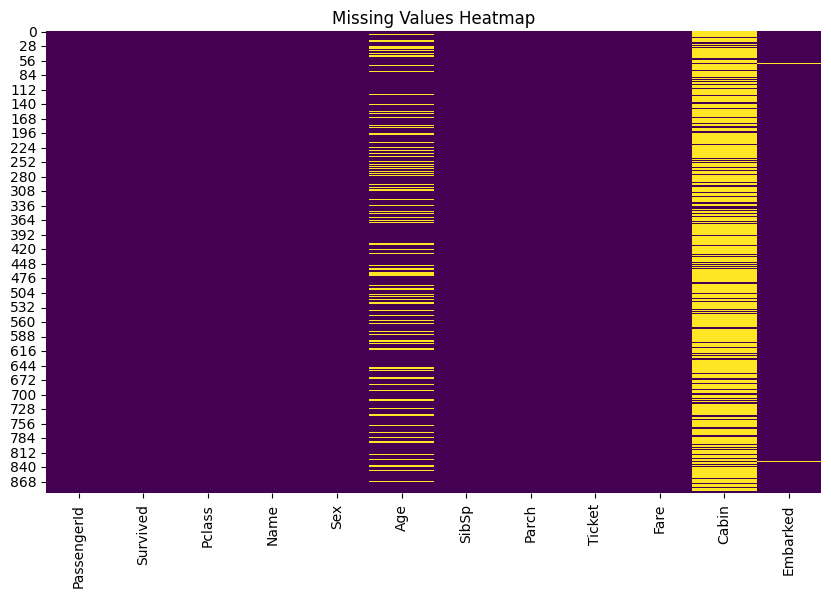

In [ ]:
print("Missing values before handling:")
print(df.isnull().sum())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

**Reasoning**:
I will impute missing values in the 'Age' column with its median and in the 'Embarked' column with its mode, then drop the 'Cabin' column due to a high percentage of missing values, and finally verify that all missing values have been handled by re-calculating and displaying the total number of missing values for each column.



In [ ]:
print("Handling missing values...")

# Impute missing 'Age' values with the median
df['Age'].fillna(df['Age'].median(), inplace=True)
print("Missing 'Age' values imputed with median.")

# Impute missing 'Embarked' values with the mode
# [0] is used to select the first mode if there are multiple modes
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
print("Missing 'Embarked' values imputed with mode.")

# Drop 'Cabin' column due to high percentage of missing values
df.drop('Cabin', axis=1, inplace=True)
print("'Cabin' column dropped.")

print("\nMissing values after handling:")
print(df.isnull().sum())

Handling missing values...
Missing 'Age' values imputed with median.
Missing 'Embarked' values imputed with mode.
'Cabin' column dropped.

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_1458/3351756383.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1458/3351756383.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

**Reasoning**:
The previous code generated `FutureWarning` messages due to the use of `inplace=True` with chained assignment in pandas. To address this and ensure future compatibility, I will update the code to explicitly assign the result of the `fillna()` operations back to the DataFrame columns, which is the recommended practice.



In [ ]:
print("Handling missing values...")

# Impute missing 'Age' values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())
print("Missing 'Age' values imputed with median.")

# Impute missing 'Embarked' values with the mode
# [0] is used to select the first mode if there are multiple modes
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("Missing 'Embarked' values imputed with mode.")

# Drop 'Cabin' column due to high percentage of missing values, ignoring error if already dropped
df.drop('Cabin', axis=1, inplace=True, errors='ignore')
print("'Cabin' column dropped (if it existed).")

print("\nMissing values after handling:")
print(df.isnull().sum())

Handling missing values...
Missing 'Age' values imputed with median.
Missing 'Embarked' values imputed with mode.
'Cabin' column dropped (if it existed).

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


**Reasoning**:
The previous code failed with a `KeyError` because the 'Cabin' column was already dropped in a prior execution. To fix this, I will add `errors='ignore'` to the `df.drop()` call, which will prevent an error if the column is not found.



In [ ]:
print("Handling missing values...")

# Impute missing 'Age' values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())
print("Missing 'Age' values imputed with median.")

# Impute missing 'Embarked' values with the mode
# [0] is used to select the first mode if there are multiple modes
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("Missing 'Embarked' values imputed with mode.")

# Drop 'Cabin' column due to high percentage of missing values, ignoring error if already dropped
df.drop('Cabin', axis=1, inplace=True, errors='ignore')
print("'Cabin' column dropped (if it existed).")

print("\nMissing values after handling:")
print(df.isnull().sum())

Handling missing values...
Missing 'Age' values imputed with median.
Missing 'Embarked' values imputed with mode.
'Cabin' column dropped (if it existed).

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Univariate Analysis

### Subtask:
Generate histograms for numerical features (e.g., Age, Fare) and count plots for categorical features (e.g., Sex, Pclass, Embarked) to understand their distributions. Ensure legends are provided for all visualizations.


**Reasoning**:
To perform univariate analysis, I will first import the necessary plotting libraries. Then, I will iterate through the specified numerical columns ('Age', 'Fare', 'SibSp', 'Parch') to create and display histograms, followed by iterating through the specified categorical columns ('Sex', 'Pclass', 'Embarked', 'Survived') to create and display count plots. Each plot will have a title, appropriate labels, and legends where applicable, as requested by the instructions.



Generating histograms for numerical features...


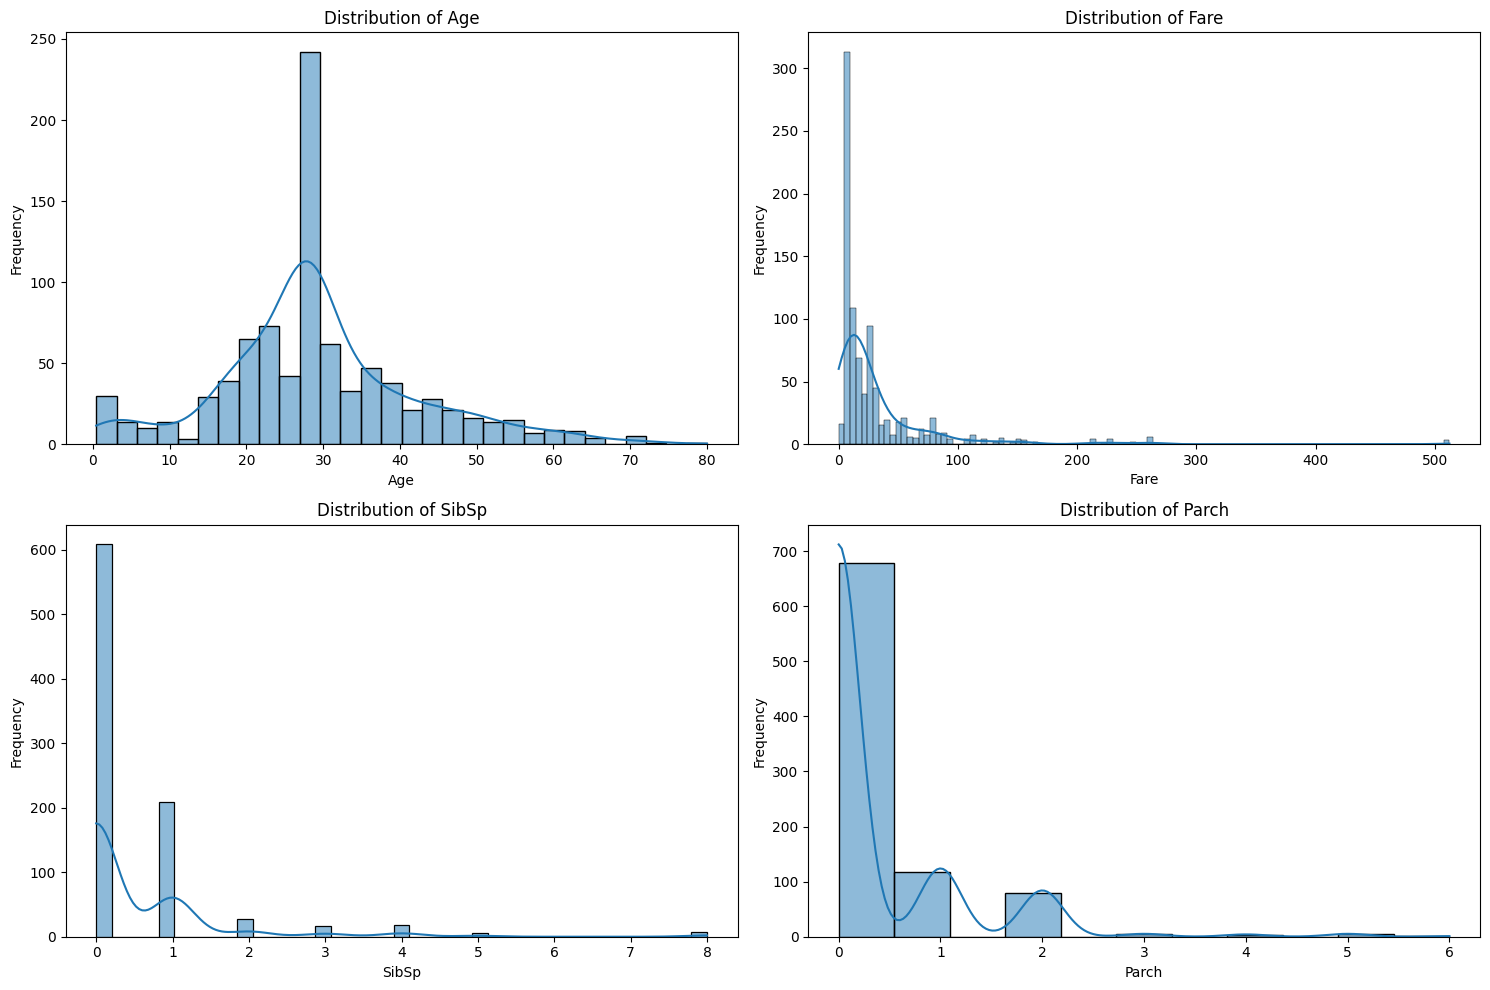

Generating count plots for categorical features...


/tmp/ipykernel_1458/129285072.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipykernel_1458/129285072.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipykernel_1458/129285072.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipykernel_1458/129285072.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for 

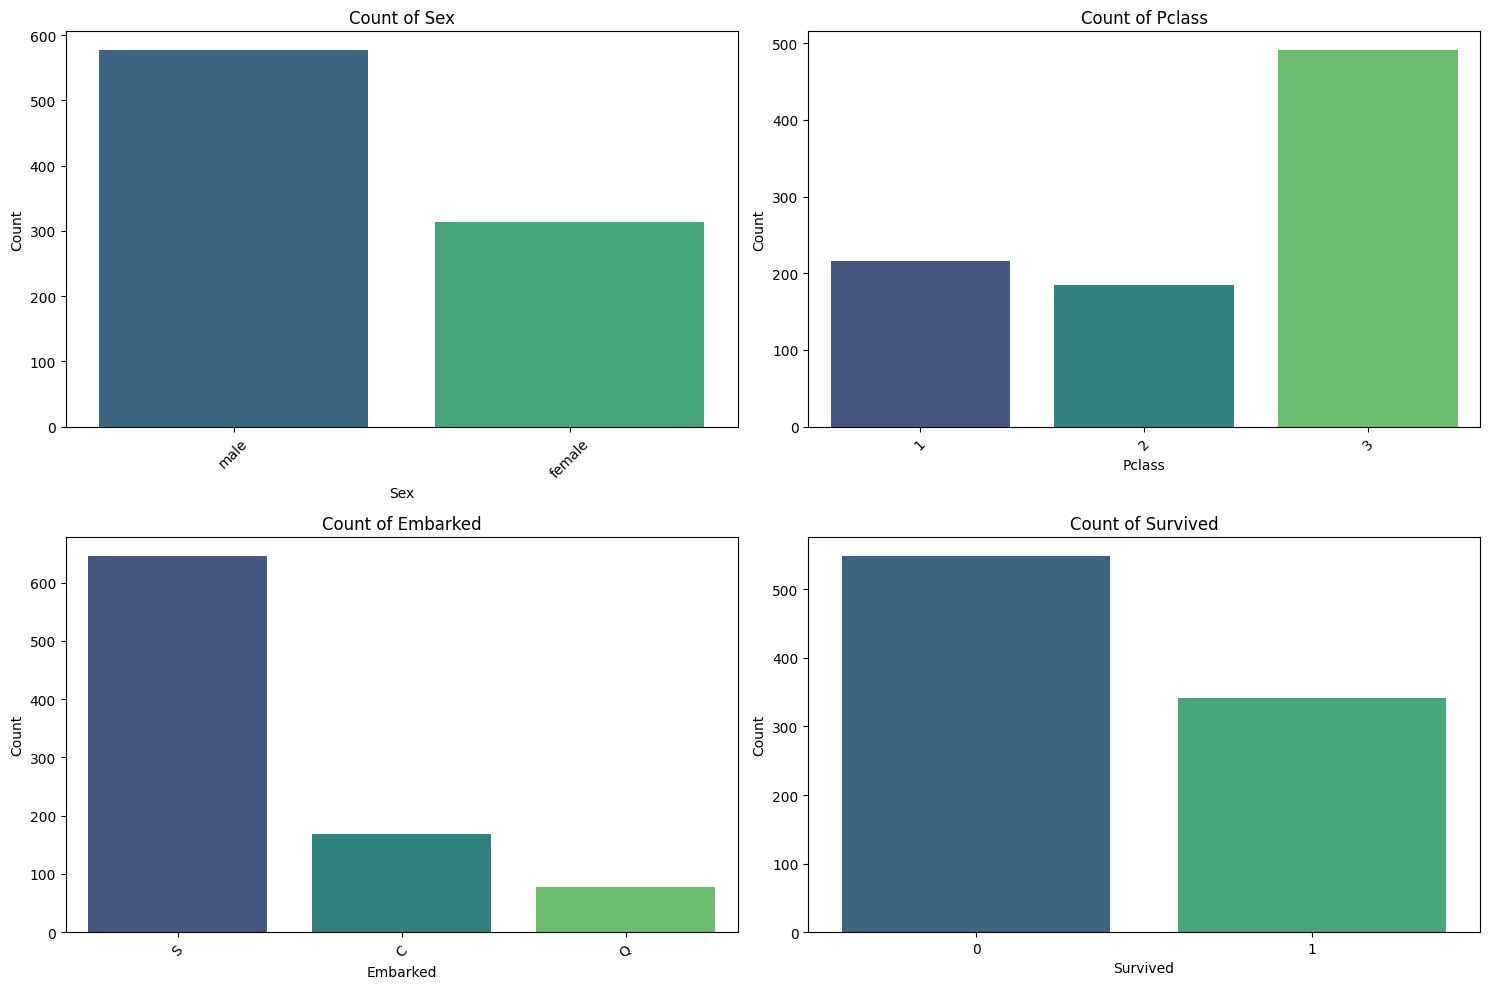

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating histograms for numerical features...")
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Generating count plots for categorical features...")
categorical_cols = ['Sex', 'Pclass', 'Embarked', 'Survived']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    if col != 'Survived': # Survived is already clear with 0 and 1
        plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated `FutureWarning` messages due to `palette` being passed to `sns.countplot` without assigning a `hue`. To fix this, I will explicitly set `hue` to the same column as `x` and set `legend=False` in the `countplot` calls, as recommended by the warning.



Generating histograms for numerical features...


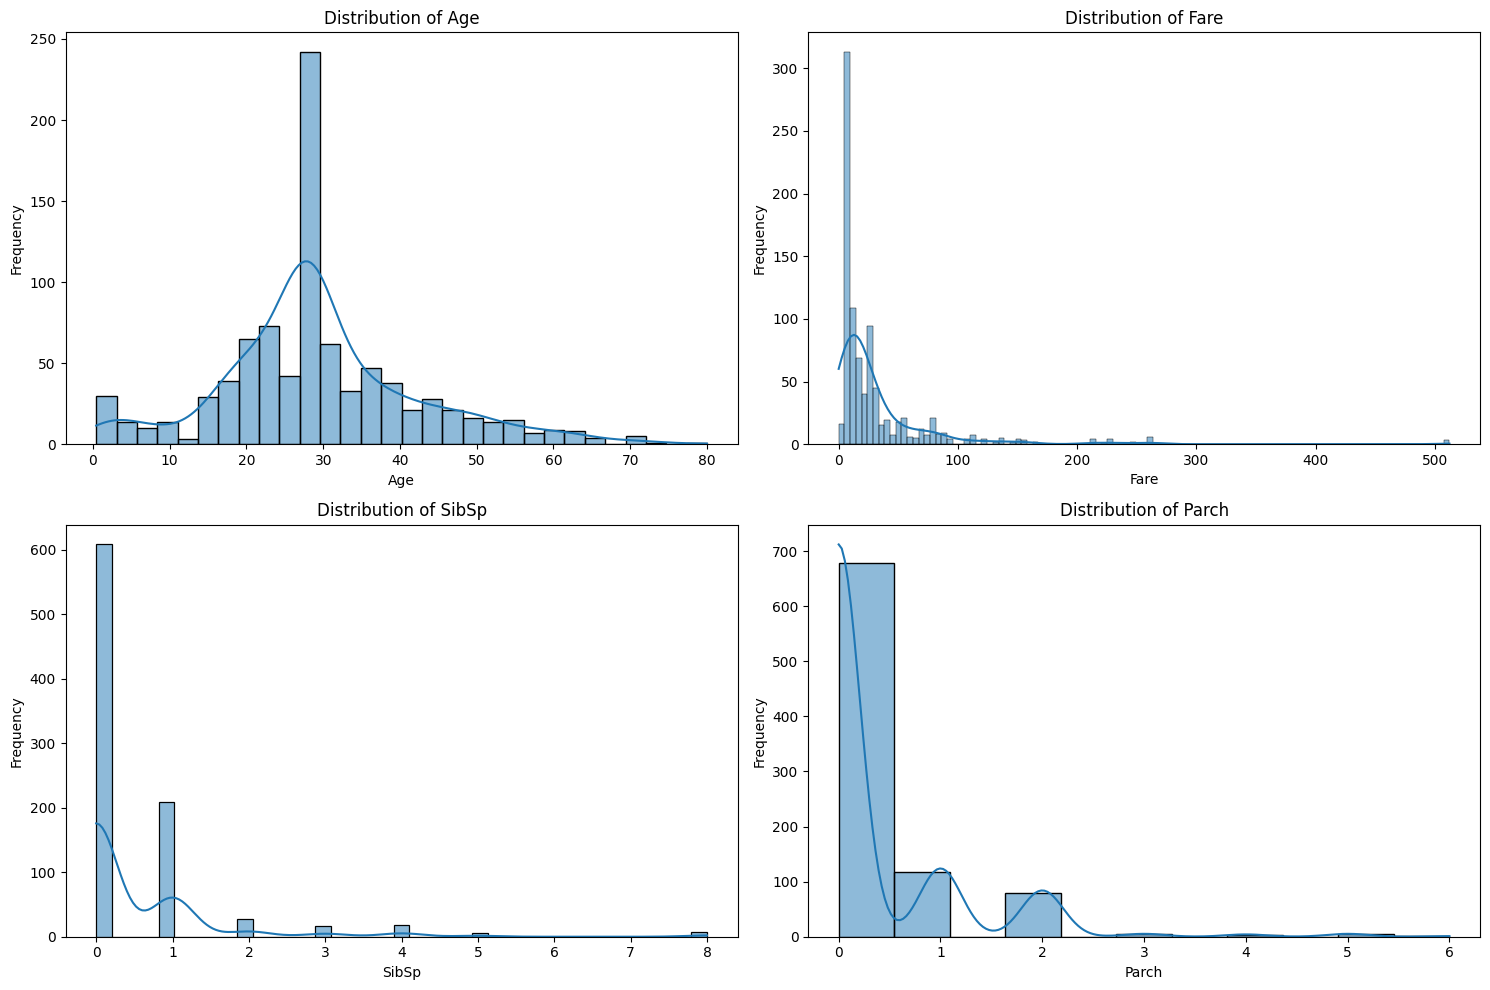

Generating count plots for categorical features...


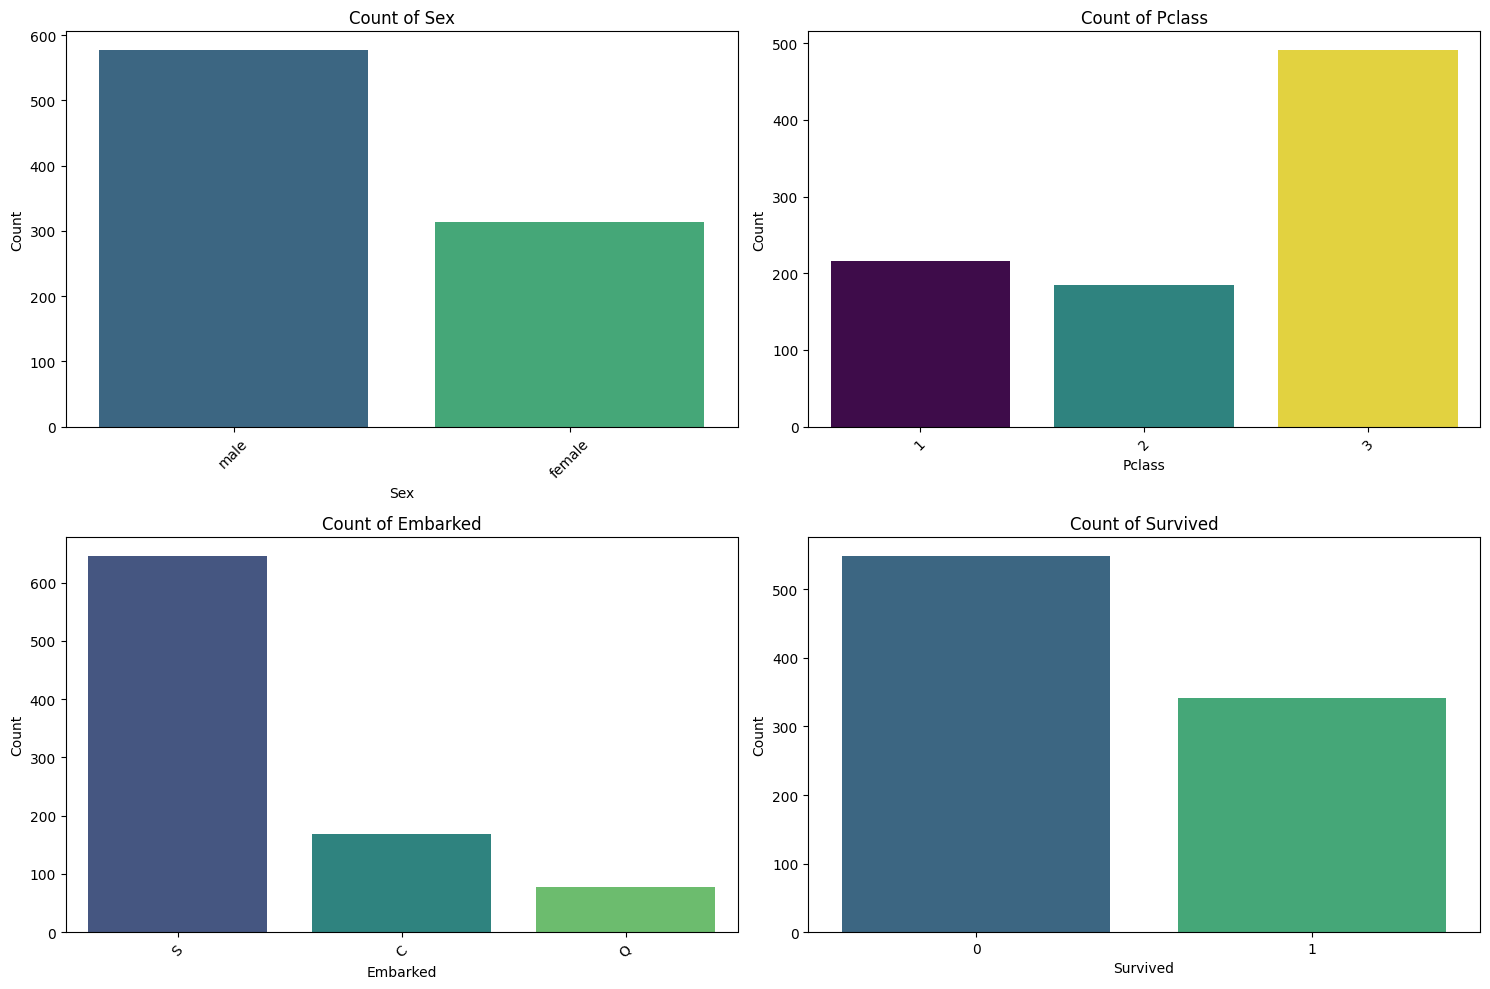

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating histograms for numerical features...")
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Generating count plots for categorical features...")
categorical_cols = ['Sex', 'Pclass', 'Embarked', 'Survived']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=df[col], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    if col != 'Survived': # Survived is already clear with 0 and 1
        plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Bivariate Analysis with Survival

### Subtask:
Explore the relationships between various features and the 'Survived' column. Create visualizations such as bar plots or violin plots to show survival rates across different categories (e.g., Pclass vs. Survived, Sex vs. Survived) and numerical ranges (e.g., Age vs. Survived, Fare vs. Survived). Ensure legends are provided for all visualizations.


**Reasoning**:
I will perform bivariate analysis by first plotting bar plots for categorical features against 'Survived' to visualize survival rates across categories, then generate violin plots for numerical features against 'Survived' to show the distribution of numerical values for survivors and non-survivors.



Generating bivariate plots for categorical features vs. Survived...


/tmp/ipykernel_1458/1063188046.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Survived', data=df, palette='viridis')
/tmp/ipykernel_1458/1063188046.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Survived', data=df, palette='viridis')
/tmp/ipykernel_1458/1063188046.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Survived', data=df, palette='viridis')


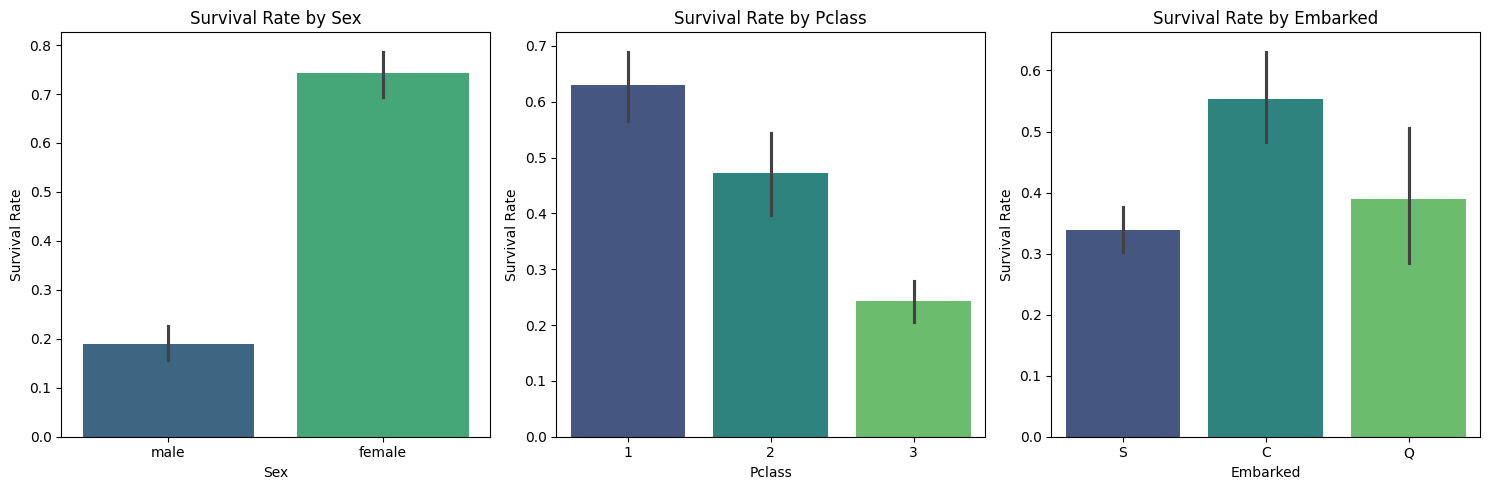


Generating bivariate plots for numerical features vs. Survived...


/tmp/ipykernel_1458/1063188046.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Survived', y=col, data=df, palette='muted')
/tmp/ipykernel_1458/1063188046.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Survived', y=col, data=df, palette='muted')
/tmp/ipykernel_1458/1063188046.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Survived', y=col, data=df, palette='muted')
/tmp/ipykernel_1458/1063188046.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. As

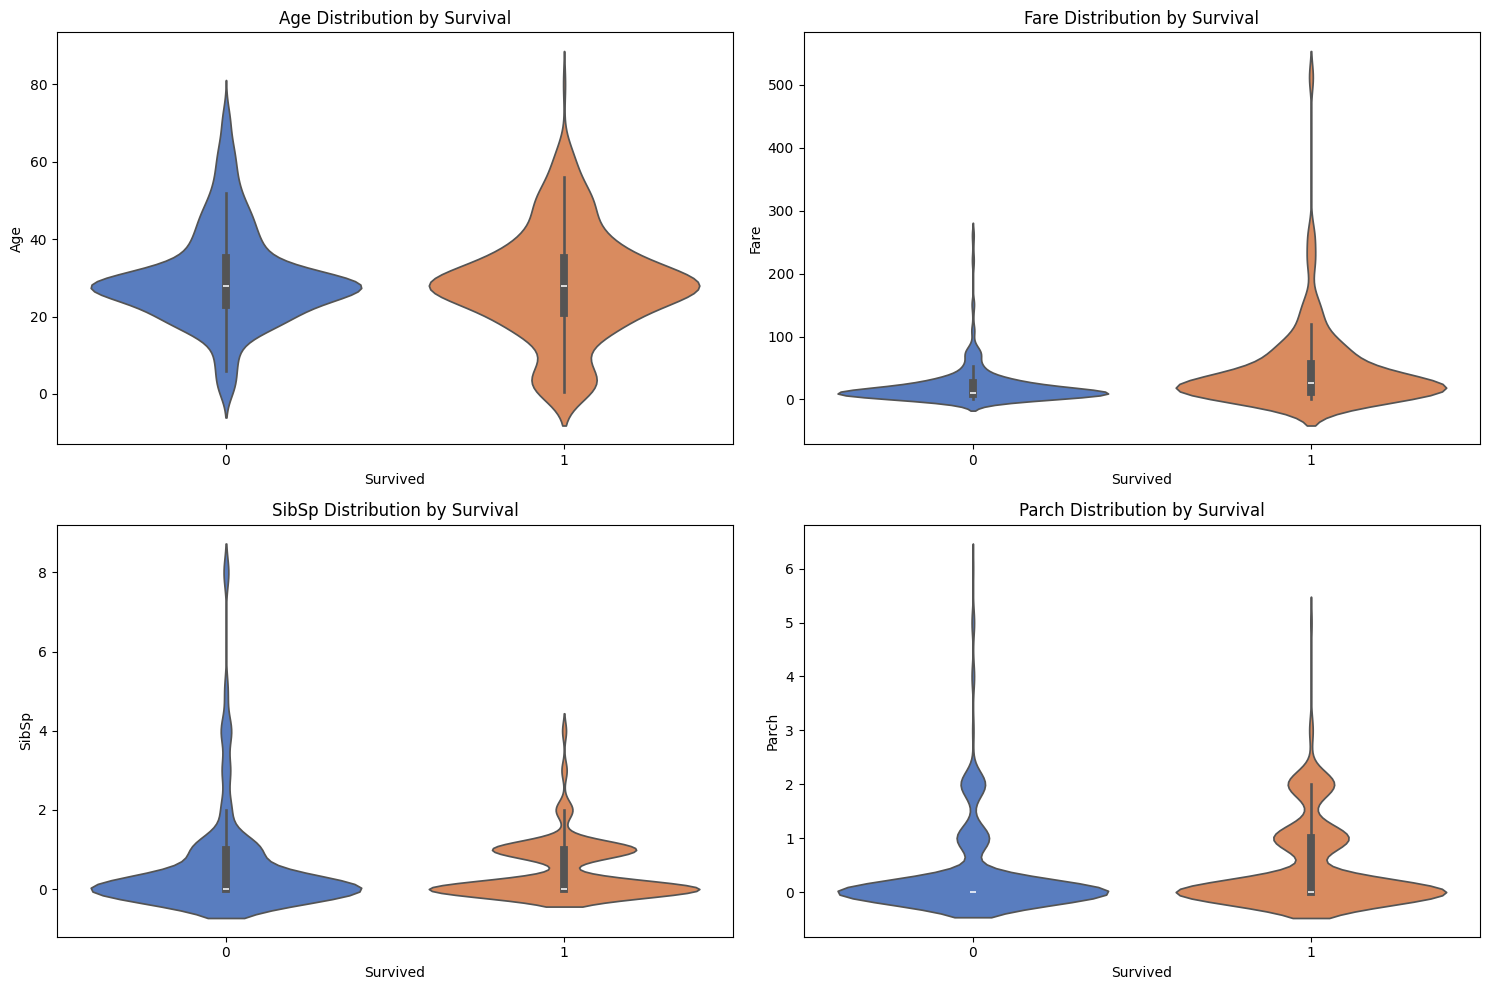

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating bivariate plots for categorical features vs. Survived...")
categorical_features = ['Sex', 'Pclass', 'Embarked']

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_features):
    plt.subplot(1, len(categorical_features), i + 1)
    sns.barplot(x=col, y='Survived', data=df, palette='viridis')
    plt.title(f'Survival Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

print("\nGenerating bivariate plots for numerical features vs. Survived...")
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.violinplot(x='Survived', y=col, data=df, palette='muted')
    plt.title(f'{col} Distribution by Survival')
    plt.xlabel('Survived')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated `FutureWarning` messages because `palette` was passed to `sns.barplot` and `sns.violinplot` without explicitly assigning a `hue`. To resolve this and prevent future warnings, I will explicitly set the `hue` parameter and `legend=False` in both the `sns.barplot` and `sns.violinplot` calls, as recommended by the warning.



Generating bivariate plots for categorical features vs. Survived...


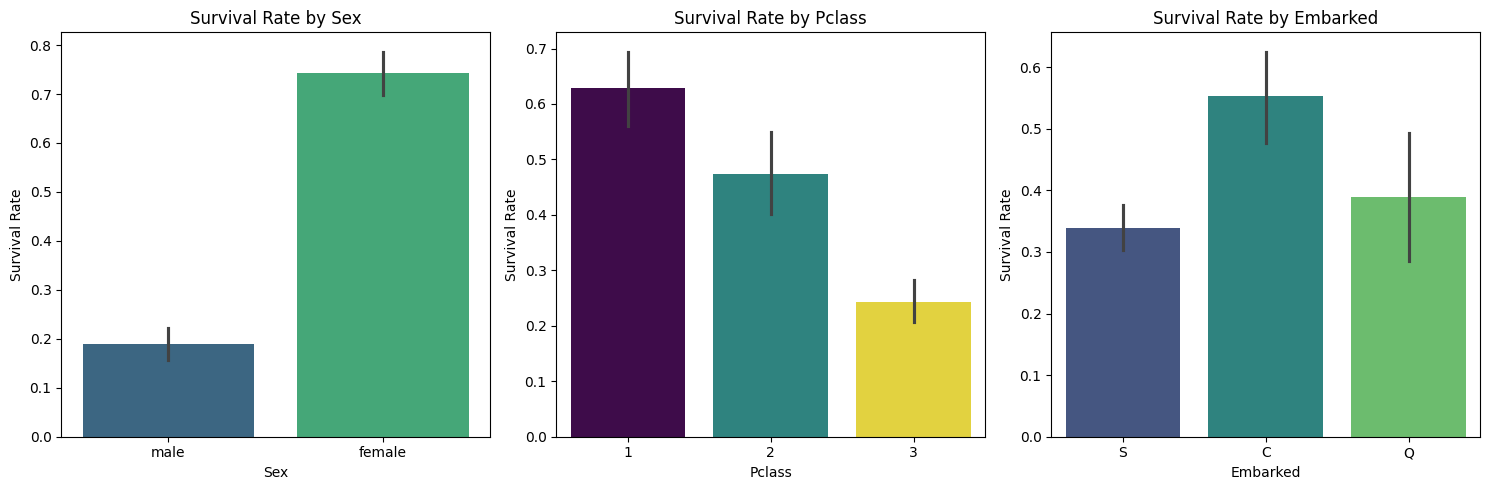


Generating bivariate plots for numerical features vs. Survived...


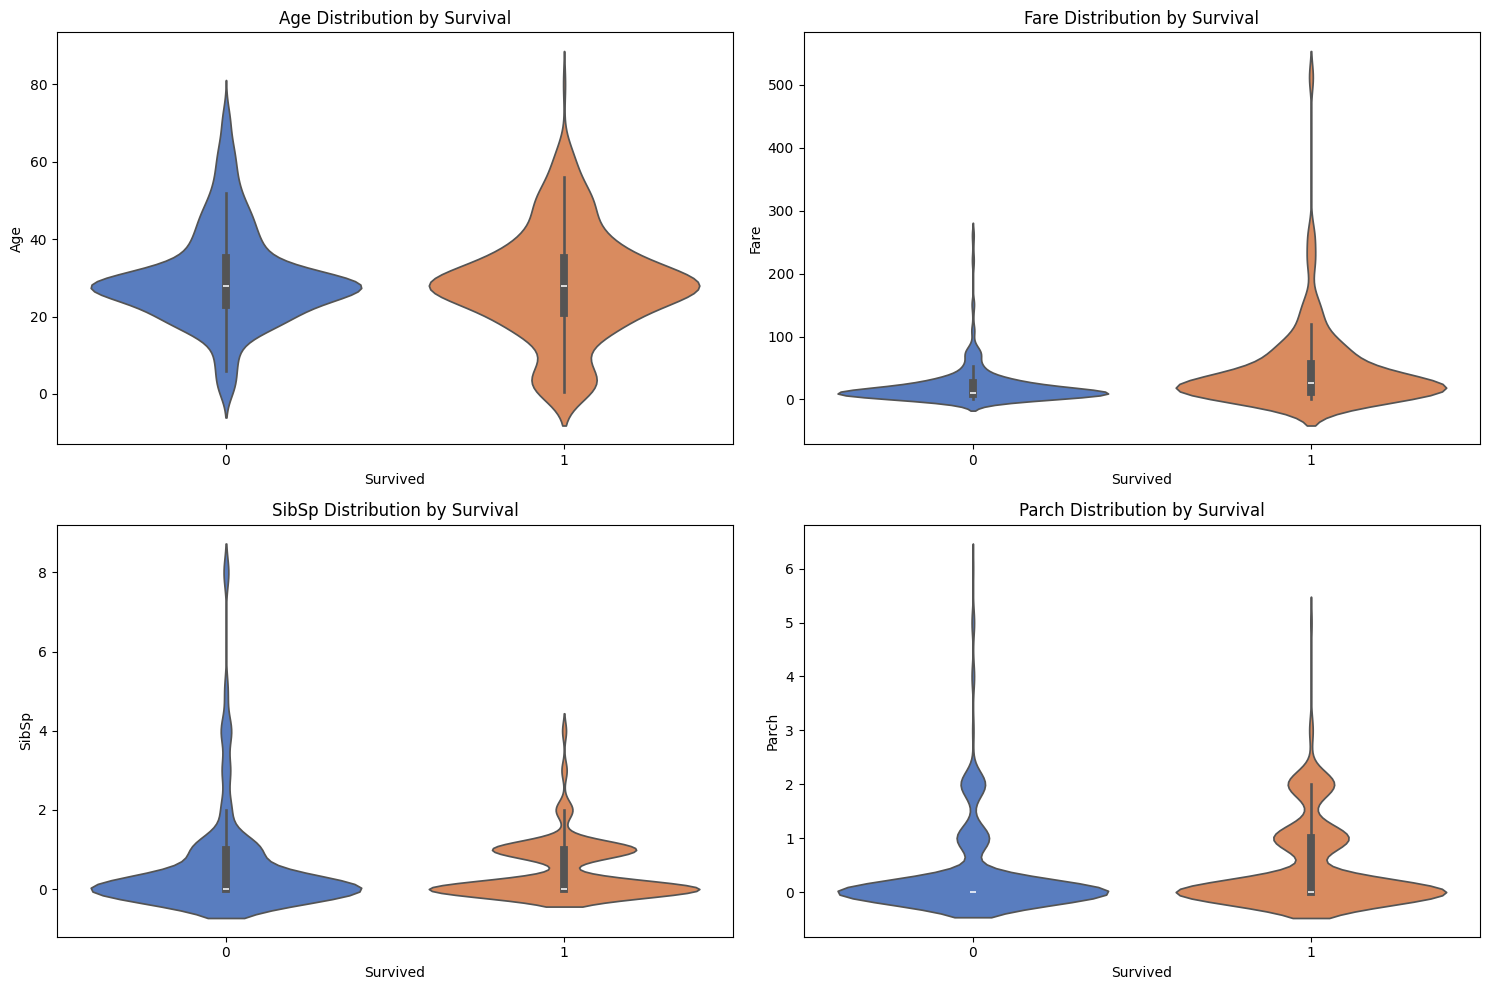

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating bivariate plots for categorical features vs. Survived...")
categorical_features = ['Sex', 'Pclass', 'Embarked']

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_features):
    plt.subplot(1, len(categorical_features), i + 1)
    sns.barplot(x=col, y='Survived', data=df, hue=col, palette='viridis', legend=False)
    plt.title(f'Survival Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

print("\nGenerating bivariate plots for numerical features vs. Survived...")
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.violinplot(x='Survived', y=col, data=df, hue='Survived', palette='muted', legend=False)
    plt.title(f'{col} Distribution by Survival')
    plt.xlabel('Survived')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Correlation Analysis

### Subtask:
Compute and visualize the correlation matrix for numerical features to understand their interdependencies.


**Reasoning**:
To visualize the correlation matrix for numerical features, I will first select the relevant numerical columns, compute their pairwise correlation using the `.corr()` method, and then generate a heatmap with `seaborn.heatmap()` to display the interdependencies, including a title and a color bar for clarity.



Computing and visualizing the correlation matrix...


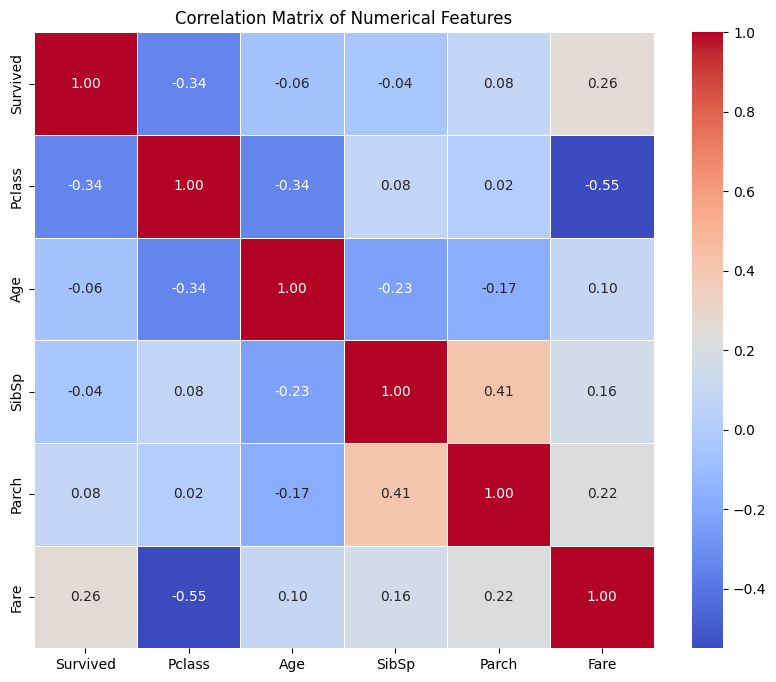

In [ ]:
print("Computing and visualizing the correlation matrix...")

# Select numerical columns for correlation analysis
# Exclude 'PassengerId' as it's an identifier and 'Name', 'Ticket' as they are not numerical
numerical_cols_for_corr = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# Compute the correlation matrix
correlation_matrix = df[numerical_cols_for_corr].corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


## Final Task

### Subtask:
Summarize the key findings and insights gained from the Exploratory Data Analysis on the Titanic dataset, including observations about survival factors and data quality.


## Summary:

### Data Analysis Key Findings

*   **Dataset Overview and Quality**: The Titanic dataset contains 891 entries and 12 columns. Initial inspection revealed significant missing data in the `Cabin` column (687 missing values, approximately 77%), moderate missing data in `Age` (177 missing values, approximately 20%), and minor missing data in `Embarked` (2 missing values).
*   **Missing Value Handling**:
    *   The `Age` column's missing values were imputed with the median age.
    *   The `Embarked` column's missing values were imputed with its mode.
    *   The `Cabin` column was dropped entirely due to its high percentage of missing values, making it unsuitable for reliable imputation or direct use.
*   **Univariate Distributions**:
    *   **Age**: The age distribution is skewed right, with a peak in young adults (around 20-30 years).
    *   **Fare**: The fare distribution is highly skewed right, indicating many passengers paid lower fares, with a few paying significantly higher fares.
    *   **Sex**: The dataset contains more male passengers than female passengers.
    *   **Pclass**: The majority of passengers were in `Pclass` 3, followed by `Pclass` 1, and then `Pclass` 2.
    *   **Survived**: Approximately 38% of the passengers survived.
*   **Bivariate Analysis (Survival Factors)**:
    *   **Gender**: Female passengers had a significantly higher survival rate than male passengers.
    *   **Passenger Class (`Pclass`)**: Passengers in `Pclass` 1 had the highest survival rate, followed by `Pclass` 2, and then `Pclass` 3, indicating a strong correlation between socio-economic status and survival.
    *   **Port of Embarkation (`Embarked`)**: Passengers who embarked from Cherbourg ('C') had a higher survival rate compared to those from Queenstown ('Q') and Southampton ('S').
    *   **Age**: Younger passengers (especially children) generally had a better chance of survival, while older passengers had a lower survival rate.
    *   **Fare**: Passengers who paid higher fares tended to have higher survival rates.
    *   **Siblings/Spouses (`SibSp`) and Parents/Children (`Parch`)**: Having 1-2 family members (siblings/spouses or parents/children) seemed to correlate with a higher survival chance compared to traveling alone or with very large families.
*   **Correlation Analysis**:
    *   There is a moderate negative correlation between `Survived` and `Pclass` (-0.34), confirming that lower passenger class is associated with lower survival.
    *   A moderate positive correlation exists between `Survived` and `Fare` (0.26), suggesting higher fares relate to higher survival.
    *   `Pclass` and `Fare` are strongly negatively correlated (-0.55), which is expected as lower classes typically pay lower fares.

### Insights or Next Steps

*   **Insight**: Survival on the Titanic was heavily influenced by social privilege (gender, passenger class, and fare paid), with women and first-class passengers having significantly higher survival rates. Age also played a role, with children having better chances.
*   **Next Steps**: Further feature engineering could be performed (e.g., creating family size, title from name, or age groups) to enhance predictive power. The dataset is now ready for predictive modeling to build a survival prediction model.


In [ ]:
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [ ]:
# To search for a specific value in a column, you can filter the DataFrame.
# For example, let's search for a specific name in the 'Name' column.
search_term = 'Braund'
found_data = df[df['Name'].str.contains(search_term, case=False, na=False)]

if not found_data.empty:
    print(f"Found entries containing '{search_term}' in the 'Name' column:")
    display(found_data)
else:
    print(f"No entries found containing '{search_term}' in the 'Name' column.")


Found entries containing 'Braund' in the 'Name' column:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
477,478,0,3,"Braund, Mr. Lewis Richard",male,29.0,1,0,3460,7.0458,S
